In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/atifkhan12/global-air-pollution-dataset-2025-2026/Global_Air_Pollution_Data_2025_2026.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)

from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

In [3]:
file_path = '/kaggle/input/datasets/atifkhan12/global-air-pollution-dataset-2025-2026/Global_Air_Pollution_Data_2025_2026.csv'

df = pd.read_csv(file_path)

df.head()

,Date,City,Latitude,Longitude,PM2.5,PM10,NO2,SO2,CO,Ozone,Aerosol_Optical_Depth,AQI_Class
0,2025-11-08 00:00:00,"Lahore, Pakistan",31.5497,74.3436,81.0,82.7,94.0,16.4,1910.0,11.0,0.19,Unhealthy
1,2025-11-08 01:00:00,"Lahore, Pakistan",31.5497,74.3436,78.2,79.6,90.9,14.4,1413.0,10.0,0.19,Unhealthy
2,2025-11-08 02:00:00,"Lahore, Pakistan",31.5497,74.3436,75.4,76.8,85.0,12.8,1060.0,12.0,0.19,Unhealthy
3,2025-11-08 03:00:00,"Lahore, Pakistan",31.5497,74.3436,72.2,73.6,72.8,11.8,863.0,20.0,0.19,Unhealthy
4,2025-11-08 04:00:00,"Lahore, Pakistan",31.5497,74.3436,69.8,71.2,57.7,11.1,811.0,31.0,0.19,Unhealthy


In [4]:
X = df.drop('AQI_Class', axis=1)

y = df['AQI_Class']

In [5]:
X['Date'] = pd.to_datetime(X['Date'])

In [6]:
X['Year'] = X['Date'].dt.year

X['Month'] = X['Date'].dt.month

X['Day'] = X['Date'].dt.day

X['Hour'] = X['Date'].dt.hour

In [7]:
if 'Date' in X.columns:
    X = X.drop('Date', axis=1)

In [8]:
city_encoder = LabelEncoder()

X['City'] = city_encoder.fit_transform(X['City'])

In [9]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

In [10]:
X.head()

,City,Latitude,Longitude,PM2.5,PM10,NO2,SO2,CO,Ozone,Aerosol_Optical_Depth,Year,Month,Day,Hour
0,4,31.5497,74.3436,81.0,82.7,94.0,16.4,1910.0,11.0,0.19,2025,11,8,0
1,4,31.5497,74.3436,78.2,79.6,90.9,14.4,1413.0,10.0,0.19,2025,11,8,1
2,4,31.5497,74.3436,75.4,76.8,85.0,12.8,1060.0,12.0,0.19,2025,11,8,2
3,4,31.5497,74.3436,72.2,73.6,72.8,11.8,863.0,20.0,0.19,2025,11,8,3
4,4,31.5497,74.3436,69.8,71.2,57.7,11.1,811.0,31.0,0.19,2025,11,8,4


In [11]:
print(X.shape)

print(y.shape)

(17472, 14)
(17472,)


In [12]:
results = []

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

results.append([
    'No Scaling',
    accuracy
])

print('No Scaling Accuracy:', accuracy)

No Scaling Accuracy: 1.0


In [14]:
scaler = StandardScaler()

X_standard = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_standard,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

results.append([
    'StandardScaler',
    accuracy
])

print('StandardScaler Accuracy:', accuracy)

StandardScaler Accuracy: 0.9997138769670959


In [15]:
scaler = MinMaxScaler()

X_minmax = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_minmax,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

results.append([
    'MinMaxScaler',
    accuracy
])

print('MinMaxScaler Accuracy:', accuracy)

MinMaxScaler Accuracy: 1.0


In [16]:
pca = PCA(n_components=5)

X_pca = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

results.append([
    'PCA',
    accuracy
])

print('PCA Accuracy:', accuracy)

PCA Accuracy: 0.9562231759656652


In [17]:
Q1 = X.quantile(0.25)

Q3 = X.quantile(0.75)

IQR = Q3 - Q1

X_no_outliers = X[
    ~((X < (Q1 - 1.5 * IQR)) |
      (X > (Q3 + 1.5 * IQR))).any(axis=1)
]

y_no_outliers = y[X_no_outliers.index]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_no_outliers,
    y_no_outliers,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

results.append([
    'Outlier Removal',
    accuracy
])

print('Outlier Removal Accuracy:', accuracy)

Outlier Removal Accuracy: 1.0


In [19]:
results_df = pd.DataFrame(

    results,

    columns=[
        'Preprocessing Method',
        'Accuracy'
    ]
)

results_df

,Preprocessing Method,Accuracy
0,No Scaling,1.000000
1,StandardScaler,0.999714
2,MinMaxScaler,1.000000
3,PCA,0.956223
4,Outlier Removal,1.000000


In [20]:
results_df.to_csv(
    'rq3_preprocessing_results.csv',
    index=False
)

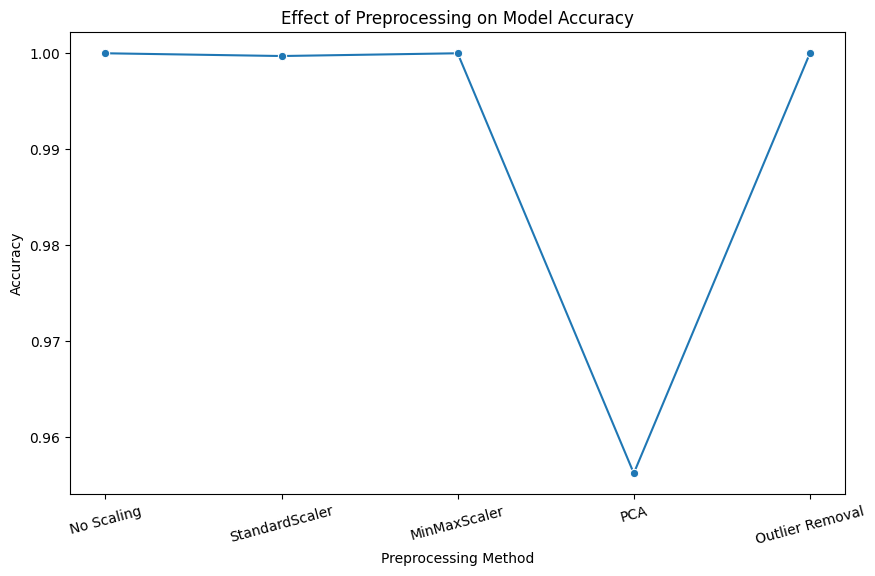

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.lineplot(
    data=results_df,
    x='Preprocessing Method',
    y='Accuracy',
    marker='o'
)

plt.title(
    'Effect of Preprocessing on Model Accuracy'
)

plt.xlabel('Preprocessing Method')

plt.ylabel('Accuracy')

plt.xticks(rotation=15)

plt.savefig(
    'rq3_preprocessing_effect.pdf',
    dpi=300,
    bbox_inches='tight'
)

plt.show()